Name: Kriti Bhattacharya
Github: Kritiin5
USC ID: 3277100685

1b. (i)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data_path = '../data/CCPP/Folds5x2_pp.xlsx'
data = pd.read_excel(data_path, sheet_name = 0)
#data.head()

In [7]:
rows, columns = data.shape
print('Number of rows: ', rows)
print('Number of columns: ', columns)

data.info()
print(data.columns)

Number of rows:  9568
Number of columns:  5
<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB
Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='str')


The dataset contains 9,568 rows and 5 columns. Each row represents one
hourly observation of the power plant. The columns AT, V, AP, and RH are
the predictor variables representing ambient temperature, exhaust
vacuum, ambient pressure, and relative humidity. PE is the response
variable representing net hourly electrical energy output.

1b. (ii)

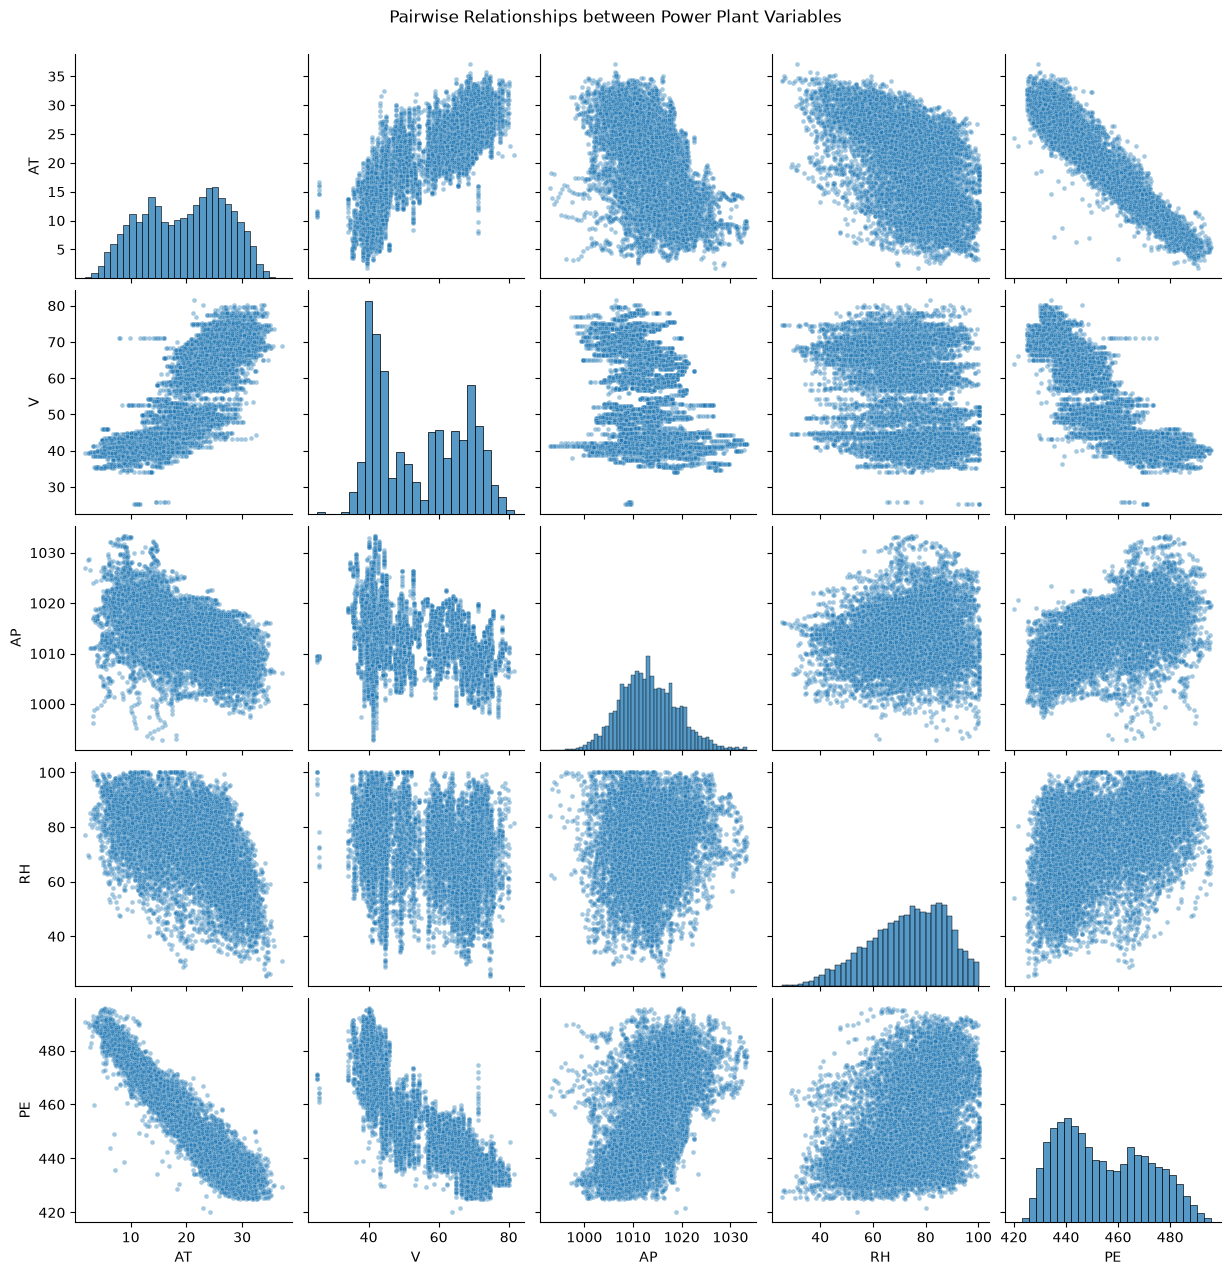

,AT,V,AP,RH,PE
AT,1.000,0.844,-0.508,-0.543,-0.948
V,0.844,1.000,-0.414,-0.312,-0.870
AP,-0.508,-0.414,1.000,0.100,0.518
RH,-0.543,-0.312,0.100,1.000,0.390
PE,-0.948,-0.870,0.518,0.390,1.000


In [10]:
pair_plot = sns.pairplot(data, diag_kind = 'hist', plot_kws = {'alpha': 0.4, 's': 12})
pair_plot.fig.suptitle('Pairwise Relationships between Power Plant Variables', y=1.02)
plt.show()

correlation_matrix = data.corr()
correlation_matrix.round(3)

AT and V have strong negative relationships with PE, while AP has a moderate positive relationship and RH has a weaker positive relationship with PE. Among the predictors, AT and V are strongly positively related, while AT is negatively related to AP and RH. The plots suggest that using multiple predictors may improve the prediction of PE.

1b. (iii)

In [11]:
summary_statistics = pd.DataFrame({
    'Mean': data.mean(),
    'Median': data.median(),
    'Minimum': data.min(),
    'Maximum': data.max(),
    'Range': data.max() - data.min(),
    'First Quartile (Q1)': data.quantile(0.25),
    'Third Quartile (Q3)': data.quantile(0.75),
    'IQR': data.quantile(0.75) - data.quantile(0.25)
})

summary_statistics.round(2)

,Mean,Median,Minimum,Maximum,Range,First Quartile (Q1),Third Quartile (Q3),IQR
AT,19.65,20.34,1.81,37.11,35.30,13.51,25.72,12.21
V,54.31,52.08,25.36,81.56,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,992.89,1033.30,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,25.56,100.16,74.60,63.33,84.83,21.50
PE,454.37,451.55,420.26,495.76,75.50,439.75,468.43,28.68


1c.

In [13]:
import statsmodels.api as sm

predictors = ['AT', 'V', 'AP', 'RH']
response = data['PE']

simple_models = {}
simple_results = []

for predictor in predictors:
    X = sm.add_constant(data[[predictor]])
    model = sm.OLS(response, X).fit()
    
    simple_models[predictor] = model
    
    simple_results.append({
        'Predictor': predictor,
        'Intercept': model.params['const'],
        'Coefficient': model.params[predictor],
        'Standard Error': model.bse[predictor],
        'p-value': model.pvalues[predictor],
        'R-squared': model.rsquared
    })

simple_regression_results = pd.DataFrame(simple_results)
simple_regression_results.round(4)

,Predictor,Intercept,Coefficient,Standard Error,p-value,R-squared
0,AT,497.0341,-2.1713,0.0074,0.0,0.8989
1,V,517.8015,-1.1681,0.0068,0.0,0.7565
2,AP,-1055.2610,1.4899,0.0251,0.0,0.2688
3,RH,420.9618,0.4557,0.0110,0.0,0.1519


Regression models

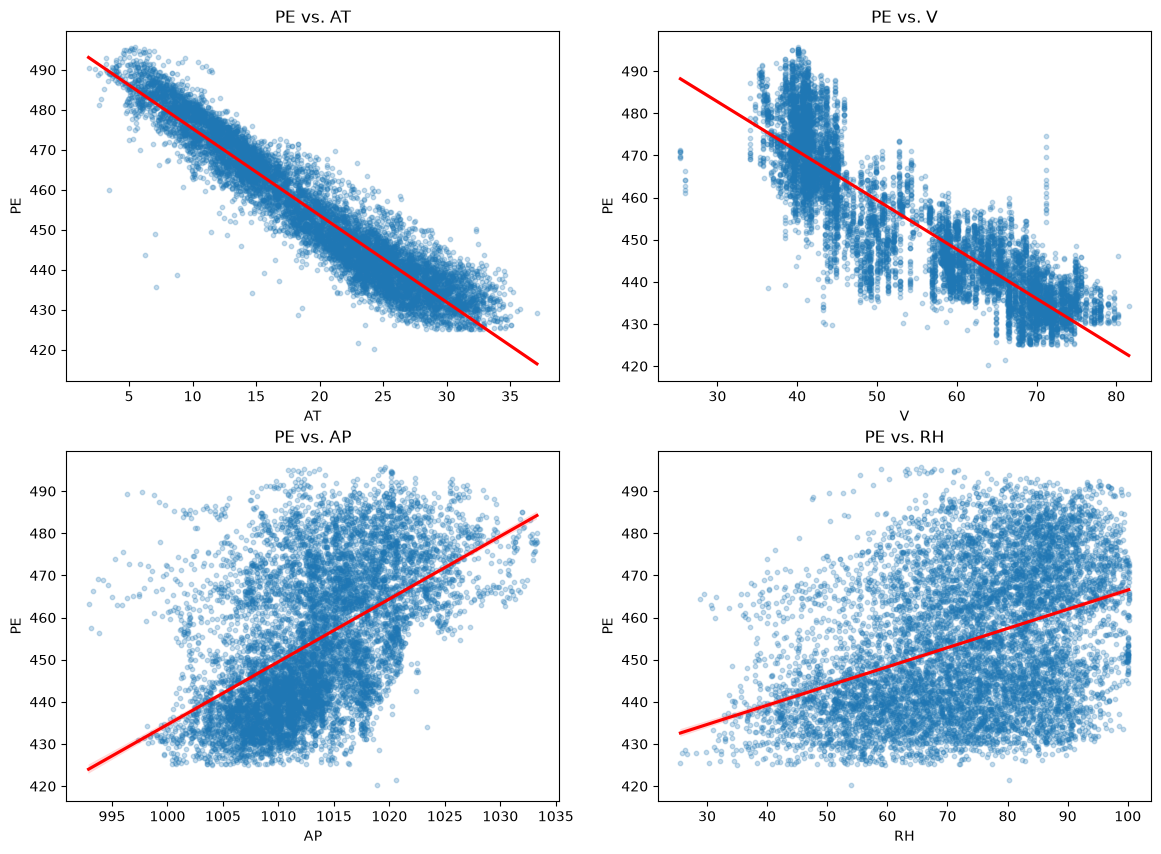

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for predictor, ax in zip(predictors, axes.flatten()):
    sns.regplot(data=data, x=predictor, y='PE', scatter_kws={'alpha': 0.25, 's': 10}, line_kws={'color': 'red'}, ax=ax)
    
    ax.set_title(f'PE vs. {predictor}')

plt.show()

Potential outliers

In [16]:
outliers = []

for feature in predictors:
    current_model = simple_models[feature]
    model_info = current_model.get_influence()
    residuals = model_info.resid_studentized_external
    
    number_of_outliers = sum(abs(residuals) > 3)
    
    outliers.append([feature, number_of_outliers])

outlier_table = pd.DataFrame(outliers, columns=['Predictor', 'Number of Potential Outliers'])

outlier_table

,Predictor,Number of Potential Outliers
0,AT,42
1,V,33
2,AP,30
3,RH,2


All four predictors have statistically significant associations with PE (p < 0.001). AT and V have negative coefficients, while AP and RH have positive coefficients.

AT is the strongest individual predictor, with an R^2 of 0.8989, followed by V with an R^2 of 0.7565. AP and RH have much lower R^2 values of 0.2688 and 0.1519, so they explain less of the variation in PE when used individually.

Using studentized residuals greater than 3 in absolute value, there are 42 potential outliers for AT, 33 for V, 30 for AP, and 2 for RH. However, I would not remove them without evidence that they are data errors, since they may be valid power plant observations.

1d.